# BQIS - Approach 2: Feature-Selected & Multi-Method Clustering
### Lanjutan dari `v1_baseline_full_features` — notebook ini mandiri (bisa jalan tanpa run notebook lain dulu)

**Tujuan notebook ini:**
1. Seleksi fitur pakai Mutual Information (bukan pakai semua 11 parameter mentah seperti v1)
2. Re-cluster pakai K-Means, DBSCAN, **dan GMM** (soft clustering — relevan karena dugaan kegagalan bersifat multi-faktor)
3. Validasi pakai **ARI + NMI** (bukan cuma ARI, biar lebih robust terhadap jumlah cluster yang beda)
4. Analisis **purity per kategori** (bukan cuma skor global) — supaya tahu kategori mana yang polanya jelas vs tumpang tindih
5. Bandingin langsung angka v2 vs v1 (baseline) di tabel akhir


In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_classif
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score
from sklearn.decomposition import PCA

pd.set_option('display.max_columns', None)
np.random.seed(42)

## 1. Load & Preprocessing
Sama seperti v1 (KNN Imputation n_neighbors=5), biar file ini mandiri dan hasilnya bisa dibandingkan apple-to-apple.

In [42]:
df = pd.read_csv("D:\\BQIS\\data\\bqis_biscuit_quality_dataset.csv") 

failure_category_ref = df['Failure_Category'].copy()
df_model = df.drop(columns=['Sample_ID', 'Batch_Code', 'Test_Date', 'Failure_Category'])
df_model = pd.get_dummies(df_model, columns=['Product_Name'], prefix='Product')
df_model['Historical_Status'] = df_model['Historical_Status'].map({'Pass': 0, 'Fail': 1})

numeric_missing_cols = ['Moisture_Content_%', 'Fat_Content_%', 'Protein_Content_%',
                         'Water_Activity_Aw', 'Acid_Insoluble_Ash_%', 'Acid_Value_mgKOHg',
                         'Peroxide_Value', 'Lead_Pb_mgkg', 'Cadmium_Cd_mgkg']
imputer = KNNImputer(n_neighbors=5, weights='distance')
df_model[numeric_missing_cols] = imputer.fit_transform(df_model[numeric_missing_cols])

fail_mask = df_model['Historical_Status'] == 1
numeric_feature_cols = numeric_missing_cols + ['Total_Plate_Count_CFUg', 'Yeast_Mold_Count_CFUg']

X_fail = df_model.loc[fail_mask, numeric_feature_cols].reset_index(drop=True)
cat_ref_fail = failure_category_ref[fail_mask].reset_index(drop=True)

print("Jumlah sampel Fail:", len(X_fail))
print(cat_ref_fail.value_counts())
print("\n>> Catatan: distribusi TIDAK seimbang (Physicochemical dominan).")
print(">> Ini salah satu alasan ARI global v1 rendah — bukan cuma soal fitur.")

Jumlah sampel Fail: 348
Failure_Category
Physicochemical    224
Heavy_Metal         69
Stability           29
Microbiological     26
Name: count, dtype: int64

>> Catatan: distribusi TIDAK seimbang (Physicochemical dominan).
>> Ini salah satu alasan ARI global v1 rendah — bukan cuma soal fitur.


## 2. Feature Selection — Mutual Information
MI mengukur seberapa besar informasi yang didapat soal `Failure_Category` kalau kita tahu nilai suatu fitur (nangkep hubungan non-linear, beda dari korelasi Pearson biasa).

**PENTING:** label `cat_ref_fail` di sini CUMA dipakai untuk RANKING fitur, bukan untuk training clustering. Clustering tetap unsupervised.

=== Mutual Information Score per Fitur (vs Failure_Category) ===
Acid_Value_mgKOHg         0.3179
Cadmium_Cd_mgkg           0.1836
Lead_Pb_mgkg              0.1491
Yeast_Mold_Count_CFUg     0.1220
Protein_Content_%         0.0712
Acid_Insoluble_Ash_%      0.0621
Peroxide_Value            0.0433
Moisture_Content_%        0.0131
Fat_Content_%             0.0035
Total_Plate_Count_CFUg    0.0001
Water_Activity_Aw         0.0000
dtype: float64


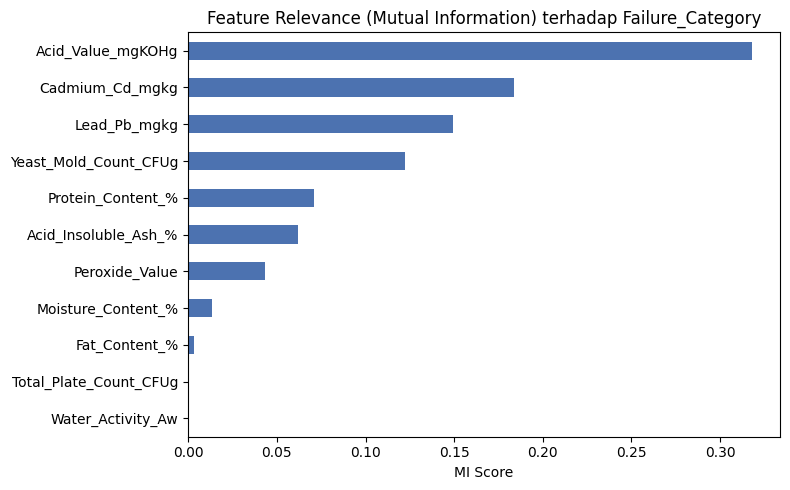


Fitur terpilih (top 5): ['Acid_Value_mgKOHg', 'Cadmium_Cd_mgkg', 'Lead_Pb_mgkg', 'Yeast_Mold_Count_CFUg', 'Protein_Content_%']
>> Bandingkan urutan ini dengan hasil SHAP di notebook 01 — kalau nyambung,
>> itu bukti tambahan bahwa fitur ini memang relevan (dua metode beda, insight sama).


In [43]:
mi_scores = mutual_info_classif(X_fail, cat_ref_fail, random_state=42)
mi_series = pd.Series(mi_scores, index=X_fail.columns).sort_values(ascending=False)

print("=== Mutual Information Score per Fitur (vs Failure_Category) ===")
print(mi_series.round(4))

plt.figure(figsize=(8,5))
mi_series.plot(kind='barh', color='#4C72B0')
plt.title("Feature Relevance (Mutual Information) terhadap Failure_Category")
plt.xlabel("MI Score")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

TOP_N = 5
selected_features = mi_series.head(TOP_N).index.tolist()
print(f"\nFitur terpilih (top {TOP_N}):", selected_features)
print(">> Bandingkan urutan ini dengan hasil SHAP di notebook 01 — kalau nyambung,")
print(">> itu bukti tambahan bahwa fitur ini memang relevan (dua metode beda, insight sama).")

In [44]:
X_selected = X_fail[selected_features]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_selected)

## 3. Clustering — K-Means
Sama seperti v1 tapi cuma pakai fitur top-N hasil MI, dan validasi sekarang pakai ARI **+ NMI**.

In [45]:
sil_scores, ari_scores_km, nmi_scores_km = {}, {}, {}
for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    sil_scores[k] = silhouette_score(X_scaled, labels)
    ari_scores_km[k] = adjusted_rand_score(cat_ref_fail, labels)
    nmi_scores_km[k] = normalized_mutual_info_score(cat_ref_fail, labels)
    print(f"k={k} -> silhouette={sil_scores[k]:.3f} | ARI={ari_scores_km[k]:.3f} | NMI={nmi_scores_km[k]:.3f}")

best_k = max(sil_scores, key=sil_scores.get)
kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
kmeans_labels = kmeans_final.fit_predict(X_scaled)

ari_kmeans_v2 = adjusted_rand_score(cat_ref_fail, kmeans_labels)
nmi_kmeans_v2 = normalized_mutual_info_score(cat_ref_fail, kmeans_labels)

print(f"\n[v2] K-Means terpilih -> k={best_k}")
print(f"[v2] ARI K-Means (feature-selected): {ari_kmeans_v2:.3f}  |  [v1 baseline]: 0.130")
print(f"[v2] NMI K-Means (feature-selected): {nmi_kmeans_v2:.3f}")

print("\nCrosstab Cluster vs Failure_Category asli:")
print(pd.crosstab(kmeans_labels, cat_ref_fail))

k=2 -> silhouette=0.208 | ARI=0.253 | NMI=0.185
k=3 -> silhouette=0.204 | ARI=0.161 | NMI=0.199
k=4 -> silhouette=0.231 | ARI=0.201 | NMI=0.280
k=5 -> silhouette=0.259 | ARI=0.277 | NMI=0.376
k=6 -> silhouette=0.284 | ARI=0.259 | NMI=0.433

[v2] K-Means terpilih -> k=6
[v2] ARI K-Means (feature-selected): 0.259  |  [v1 baseline]: 0.130
[v2] NMI K-Means (feature-selected): 0.433

Crosstab Cluster vs Failure_Category asli:
Failure_Category  Heavy_Metal  Microbiological  Physicochemical  Stability
row_0                                                                     
0                           0                8               74          0
1                           2                0               95          0
2                          35                0               10          0
3                          31                0               12          0
4                           1                4               33         29
5                           0               14    

## 4. Clustering — DBSCAN
Cek beberapa nilai `eps` biar dapet keseimbangan noise vs jumlah cluster yang wajar.

In [46]:
for eps in np.arange(0.3, 1.4, 0.1):
    db = DBSCAN(eps=round(eps,1), min_samples=5)
    labels = db.fit_predict(X_scaled)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)
    print(f"eps={eps:.1f} -> n_clusters={n_clusters}, noise={n_noise} ({n_noise/len(labels)*100:.1f}%)")

EPS_CHOSEN = 0.8  # sesuaikan setelah lihat hasil loop di atas
db_final = DBSCAN(eps=EPS_CHOSEN, min_samples=5)
dbscan_labels = db_final.fit_predict(X_scaled)
n_noise = list(dbscan_labels).count(-1)

ari_dbscan_v2 = adjusted_rand_score(cat_ref_fail, dbscan_labels)
nmi_dbscan_v2 = normalized_mutual_info_score(cat_ref_fail, dbscan_labels)

print(f"\n[v2] DBSCAN (eps={EPS_CHOSEN}) -> noise={n_noise}/{len(X_scaled)} ({n_noise/len(X_scaled)*100:.1f}%)")
print(f"[v2] ARI DBSCAN (feature-selected): {ari_dbscan_v2:.3f}  |  [v1 baseline]: 0.281")
print(f"[v2] NMI DBSCAN (feature-selected): {nmi_dbscan_v2:.3f}")

eps=0.3 -> n_clusters=1, noise=343 (98.6%)
eps=0.4 -> n_clusters=2, noise=330 (94.8%)
eps=0.5 -> n_clusters=6, noise=289 (83.0%)
eps=0.6 -> n_clusters=6, noise=232 (66.7%)
eps=0.7 -> n_clusters=2, noise=188 (54.0%)


eps=0.8 -> n_clusters=6, noise=136 (39.1%)
eps=0.9 -> n_clusters=2, noise=105 (30.2%)
eps=1.0 -> n_clusters=2, noise=71 (20.4%)
eps=1.1 -> n_clusters=1, noise=52 (14.9%)
eps=1.2 -> n_clusters=1, noise=37 (10.6%)
eps=1.3 -> n_clusters=1, noise=31 (8.9%)

[v2] DBSCAN (eps=0.8) -> noise=136/348 (39.1%)
[v2] ARI DBSCAN (feature-selected): 0.239  |  [v1 baseline]: 0.281
[v2] NMI DBSCAN (feature-selected): 0.218


## 5. Clustering — Gaussian Mixture Model (Soft Clustering)
Beda dari K-Means/DBSCAN (hard assignment), GMM kasih **probabilitas** tiap sampel ke tiap cluster.
Ini penting karena dugaan awal (README v1): kegagalan bisa **multi-faktor**, jadi sampel yang "campuran"
antar kategori bisa lebih jujur direpresentasikan sebagai probabilitas ketimbang dipaksa satu label.

In [47]:
bic_scores = {}
for k in range(2, 7):
    gmm_test = GaussianMixture(n_components=k, random_state=42, n_init=10)
    gmm_test.fit(X_scaled)
    bic_scores[k] = gmm_test.bic(X_scaled)
    print(f"k={k} -> BIC={bic_scores[k]:.1f}")

best_k_gmm = min(bic_scores, key=bic_scores.get)
print(f"\nJumlah komponen optimal GMM (BIC terendah): {best_k_gmm}")

gmm = GaussianMixture(n_components=best_k_gmm, random_state=42, n_init=10)
gmm_labels = gmm.fit_predict(X_scaled)
gmm_proba = gmm.predict_proba(X_scaled)

ari_gmm_v2 = adjusted_rand_score(cat_ref_fail, gmm_labels)
nmi_gmm_v2 = normalized_mutual_info_score(cat_ref_fail, gmm_labels)

print(f"[v2] ARI GMM (feature-selected): {ari_gmm_v2:.3f}")
print(f"[v2] NMI GMM (feature-selected): {nmi_gmm_v2:.3f}")

# Contoh: sampel dengan probabilitas paling "ambigu" (mendekati merata di 2+ cluster)
max_proba = gmm_proba.max(axis=1)
ambiguous_idx = np.argsort(max_proba)[:5]
print("\n5 sampel paling 'ambigu' (confidence cluster paling rendah):")
ambig_df = pd.DataFrame(gmm_proba[ambiguous_idx].round(3), columns=[f"Cluster_{i}" for i in range(best_k_gmm)])
ambig_df['Failure_Category_Asli'] = cat_ref_fail.iloc[ambiguous_idx].values
print(ambig_df)
print("\n>> Sampel-sampel ini kandidat kuat untuk narasi 'kegagalan multi-faktor' di exec summary.")

k=2 -> BIC=4289.1
k=3 -> BIC=4155.3
k=4 -> BIC=4144.5
k=5 -> BIC=4207.7
k=6 -> BIC=4277.0

Jumlah komponen optimal GMM (BIC terendah): 4
[v2] ARI GMM (feature-selected): 0.101
[v2] NMI GMM (feature-selected): 0.130

5 sampel paling 'ambigu' (confidence cluster paling rendah):
   Cluster_0  Cluster_1  Cluster_2  Cluster_3 Failure_Category_Asli
0      0.002      0.006      0.494      0.498       Physicochemical
1      0.025      0.500      0.074      0.401       Physicochemical
2      0.000      0.003      0.493      0.505       Physicochemical
3      0.202      0.003      0.283      0.512       Physicochemical
4      0.000      0.005      0.474      0.520       Physicochemical

>> Sampel-sampel ini kandidat kuat untuk narasi 'kegagalan multi-faktor' di exec summary.


## Validasi Clustering: ARI & NMI

Karena K-Means/DBSCAN bersifat *unsupervised* (tidak diberi tahu kategori kegagalan asli),
kami membandingkan hasil clustering terhadap `Failure_Category` historis menggunakan dua
metrik komplementer:

- **ARI (Adjusted Rand Index)**: mengukur kesesuaian pada level PASANGAN sampel, sudah
  dikoreksi terhadap bias random assignment. Range -1 s.d. 1 (1 = sempurna, 0 = setara
  tebakan acak).
- **NMI (Normalized Mutual Information)**: mengukur seberapa banyak informasi yang
  "dibagi" antara cluster dan kategori asli. Range 0 s.d. 1, lebih toleran terhadap
  perbedaan jumlah cluster dibanding ARI.

Keduanya dipakai BERSAMAAN sebagai validasi silang -- kalau ARI dan NMI konsisten satu
sama lain, hasil clustering dianggap stabil, bukan artefak dari satu metrik saja.

**Catatan:** ARI/NMI hanya valid dihitung jika ground truth (kategori asli) tersedia.
Jika data produksi nanti tidak memiliki sub-kategori kegagalan, validasi otomatis
fallback ke Silhouette Score (lihat fungsi `suggest_eps` dan `select_features`).

## 6. Purity per Kategori
Jangan cuma lihat skor global (ARI/NMI) — cek kategori mana yang **polanya jelas** vs **tumpang tindih**.
Ini yang dipakai buat narasi jujur di exec summary (bukan klaim "semua kategori ketemu rapi").

In [48]:
def purity_per_category(cluster_labels, true_labels, method_name):
    ct = pd.crosstab(true_labels, cluster_labels)
    print(f"--- Purity per Kategori ({method_name}) ---")
    for cat in ct.index:
        row = ct.loc[cat]
        dominant_cluster = row.idxmax()
        purity = row.max() / row.sum()
        print(f"  {cat:18s} -> mayoritas di cluster {dominant_cluster}, purity={purity:.2f} (n={row.sum()})")
    print()

purity_per_category(kmeans_labels, cat_ref_fail, "K-Means v2")
purity_per_category(gmm_labels, cat_ref_fail, "GMM v2")

--- Purity per Kategori (K-Means v2) ---
  Heavy_Metal        -> mayoritas di cluster 2, purity=0.51 (n=69)
  Microbiological    -> mayoritas di cluster 5, purity=0.54 (n=26)
  Physicochemical    -> mayoritas di cluster 1, purity=0.42 (n=224)
  Stability          -> mayoritas di cluster 4, purity=1.00 (n=29)

--- Purity per Kategori (GMM v2) ---
  Heavy_Metal        -> mayoritas di cluster 3, purity=0.36 (n=69)
  Microbiological    -> mayoritas di cluster 0, purity=0.69 (n=26)
  Physicochemical    -> mayoritas di cluster 3, purity=0.59 (n=224)
  Stability          -> mayoritas di cluster 3, purity=0.72 (n=29)



## 7. Visualisasi Pembanding (PCA 2D)

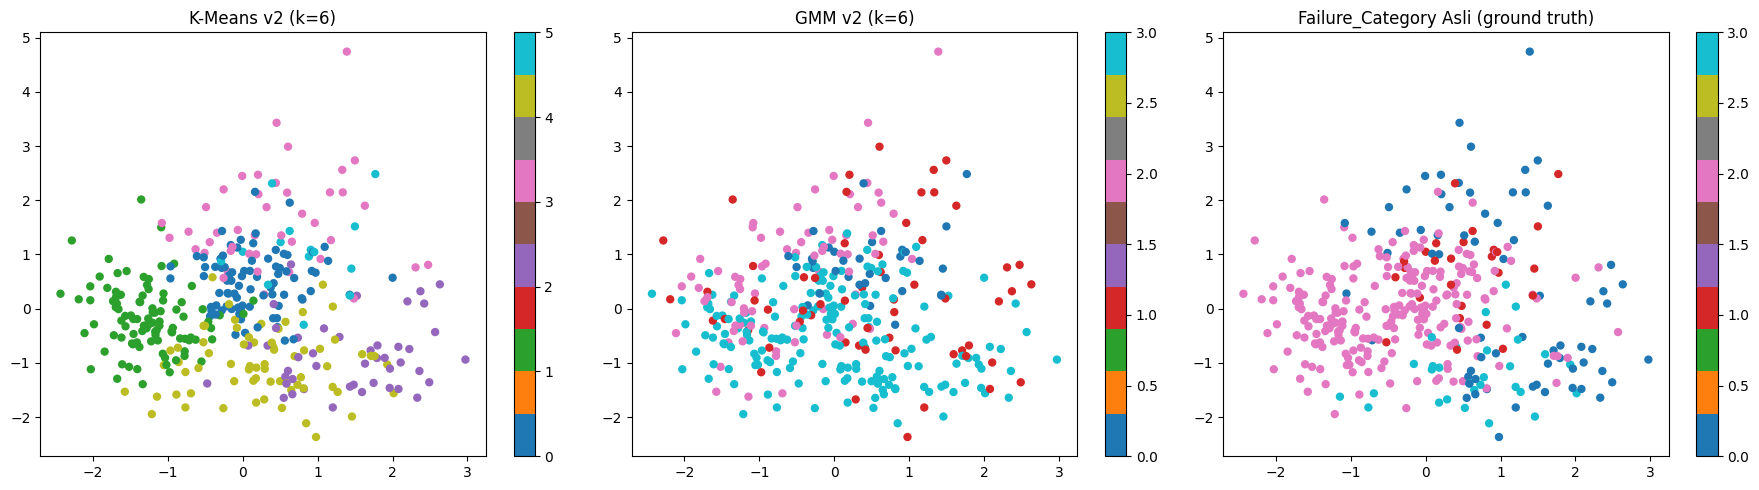

In [49]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
titles = [f"K-Means v2 (k={best_k})", f"GMM v2 (k={best_k})", "Failure_Category Asli (ground truth)"]
label_sets = [kmeans_labels, gmm_labels, cat_ref_fail.astype('category').cat.codes]

for ax, title, labels in zip(axes, titles, label_sets):
    sc = ax.scatter(X_pca[:,0], X_pca[:,1], c=labels, cmap='tab10', s=25)
    ax.set_title(title)
    plt.colorbar(sc, ax=ax)
plt.tight_layout()
plt.show()

## 8. Ringkasan Perbandingan v1 vs v2
Tabel ini yang di-copy ke `README.md` (bagian Approach 2 — Status: CONCLUDED).

In [50]:
comparison = pd.DataFrame({
    "Metode": ["K-Means", "DBSCAN", "GMM"],
    "ARI_v1_baseline": [0.130, 0.281, "-"],
    "ARI_v2_feature_selected": [round(ari_kmeans_v2,3), round(ari_dbscan_v2,3), round(ari_gmm_v2,3)],
    "NMI_v2_feature_selected": [round(nmi_kmeans_v2,3), round(nmi_dbscan_v2,3), round(nmi_gmm_v2,3)],
})
print(comparison.to_string(index=False))
print("\nFitur terpilih (top-N MI):", selected_features)
print(f"\n>> Interpretasi singkat: kalau ARI v2 naik signifikan dari v1, feature selection terbukti membantu.")
print(">> Kalau naiknya tipis, itu BUKAN kegagalan proyek — itu temuan bahwa struktur kegagalan")
print(">> (terutama Physicochemical) bersifat kontinu/multi-faktor, bukan diskrit rapi.")
print(">> Gunakan purity per kategori (section 6) untuk narasi yang jujur & presisi di exec summary.")

 Metode ARI_v1_baseline  ARI_v2_feature_selected  NMI_v2_feature_selected
K-Means            0.13                    0.259                    0.433
 DBSCAN           0.281                    0.239                    0.218
    GMM               -                    0.101                    0.130

Fitur terpilih (top-N MI): ['Acid_Value_mgKOHg', 'Cadmium_Cd_mgkg', 'Lead_Pb_mgkg', 'Yeast_Mold_Count_CFUg', 'Protein_Content_%']

>> Interpretasi singkat: kalau ARI v2 naik signifikan dari v1, feature selection terbukti membantu.
>> Kalau naiknya tipis, itu BUKAN kegagalan proyek — itu temuan bahwa struktur kegagalan
>> (terutama Physicochemical) bersifat kontinu/multi-faktor, bukan diskrit rapi.
>> Gunakan purity per kategori (section 6) untuk narasi yang jujur & presisi di exec summary.


## 9. Simpan Hasil

In [51]:
result_v2 = df.loc[fail_mask, ['Sample_ID', 'Batch_Code', 'Product_Name']].reset_index(drop=True)
result_v2['Failure_Category_Original'] = cat_ref_fail
result_v2['KMeans_Cluster_v2'] = kmeans_labels
result_v2['DBSCAN_Cluster_v2'] = dbscan_labels
result_v2['GMM_Cluster_v2'] = gmm_labels
result_v2['GMM_Confidence'] = gmm_proba.max(axis=1).round(3)

result_v2.to_csv("bqis_clustering_result_v2.csv", index=False)
comparison.to_csv("bqis_v1_vs_v2_comparison.csv", index=False)
print("Saved: bqis_clustering_result_v2.csv")
print("Saved: bqis_v1_vs_v2_comparison.csv")

Saved: bqis_clustering_result_v2.csv
Saved: bqis_v1_vs_v2_comparison.csv
